[TIMER] Load data: 0.01s
[TIMER] Feature engineering: 5.72s
Train rows: 6649009
Holdout rows: 618561

CV RESULTS
 month    auc     f1  accuracy
     7 0.7924 0.4715    0.8281
     8 0.7855 0.4557    0.8301
     9 0.7598 0.3711    0.8703
    10 0.7608 0.3509    0.8532
    11 0.7456 0.3435    0.8688

FINAL HOLDOUT METRICS
model    auc     f1  accuracy    rmse     mae
  xgb 0.7561 0.3676     0.825 49.2872 21.2696


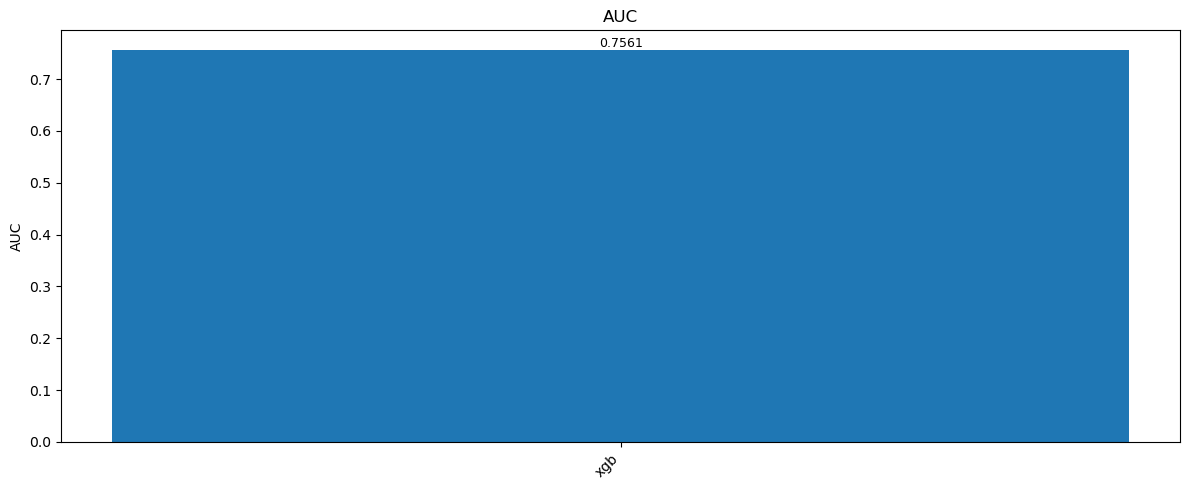

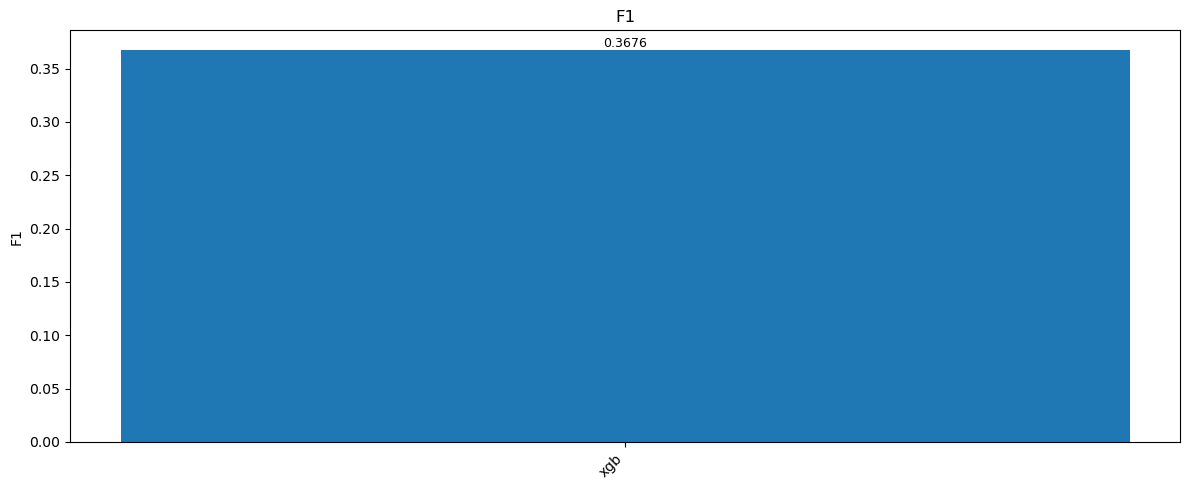

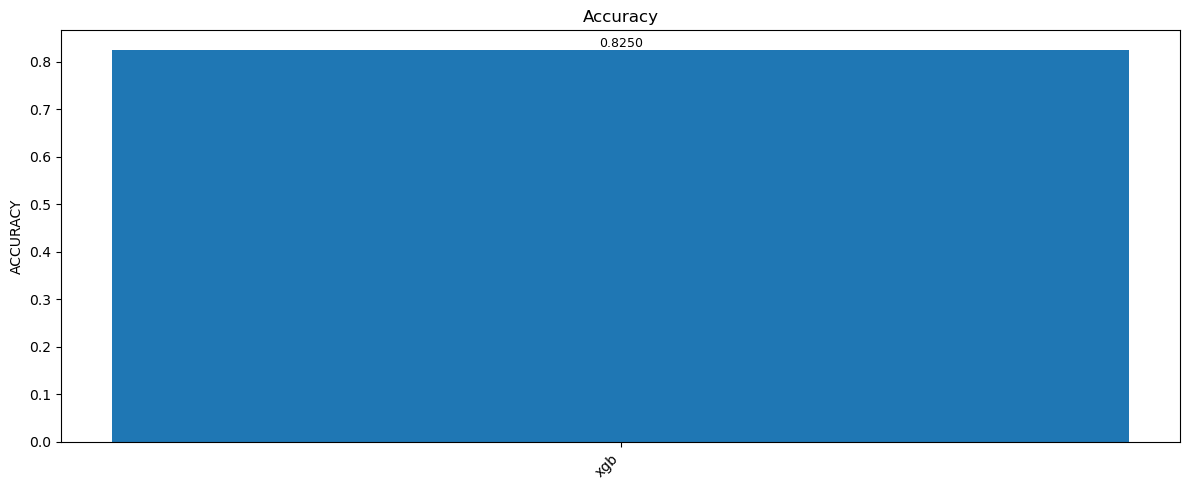

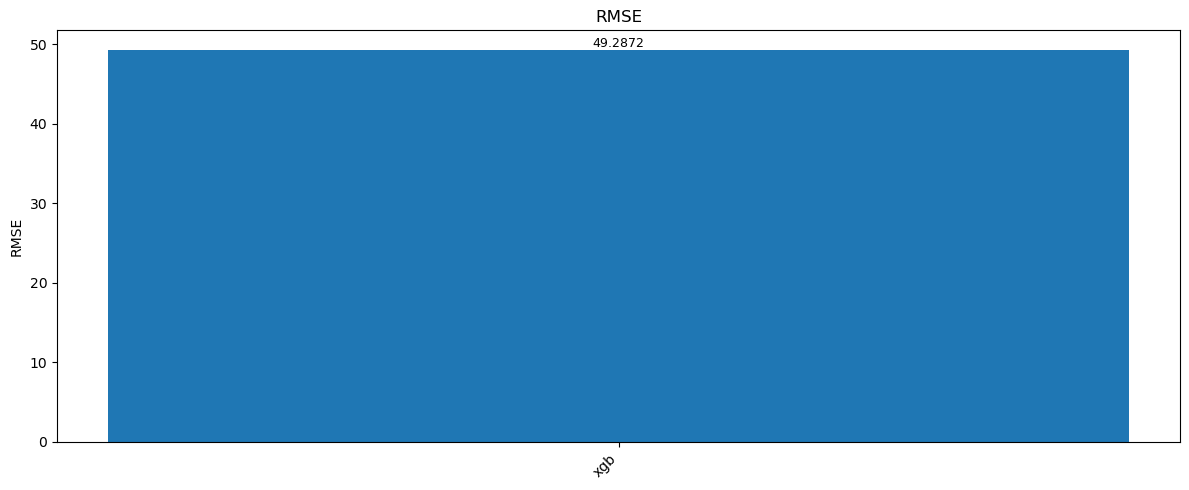

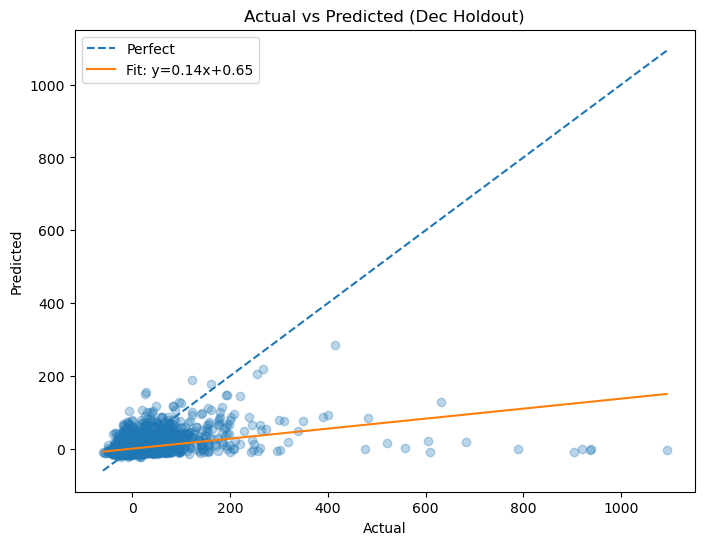


NOTE: cum_arr_delay_aircraft_day was replaced with prior (shifted) version to avoid leakage.
[TIMER] TOTAL TIME: 111.73s


In [ ]:
from pathlib import Path
import sys
import importlib
import warnings
warnings.filterwarnings("ignore")

import time

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    roc_curve,
)

from xgboost import XGBClassifier, XGBRegressor


# ============================================================
# TIMER HELPERS
# ============================================================

GLOBAL_START = time.perf_counter()

def timer_log(label, start_time):
    elapsed = time.perf_counter() - start_time
    print(f"[TIMER] {label}: {elapsed:.2f}s")


# ============================================================
# 1. LOAD DATA
# ============================================================

t0 = time.perf_counter()

pl.Config.set_tbl_rows(1000)
pl.Config.set_tbl_cols(100)
pl.Config.set_tbl_width_chars(200)

current = Path.cwd()
while current.name != "shared-notebooks":
    if current.parent == current:
        raise RuntimeError("Could not locate shared-notebooks directory")
    current = current.parent

utils_path = current / "common_utils" / "python"
if str(utils_path) not in sys.path:
    sys.path.append(str(utils_path))

import load_flight_data
importlib.reload(load_flight_data)

lf = load_flight_data.load_flight_data(file_name="flights_canonical_2019.parquet")

timer_log("Load data", t0)


# ============================================================
# 2. FEATURES
# ============================================================

t0 = time.perf_counter()

RAW_FEATURES = [
    "flight_id",
    "tail_number",
    "reporting_airline",
    "origin",
    "dest",
    "route_key",
    "distance",
    "flight_date",

    # local calendar/time features
    "dep_hour_local",
    "dep_weekday_local",
    "dep_month_local",

    # UTC timestamps for sequencing
    "dep_ts_sched_utc",
    "dep_ts_actual_utc",
    "arr_ts_sched_utc",
    "arr_ts_actual_utc",

    # weather
    "dep_temp_c",
    "dep_wind_speed_m_s",
    "dep_wind_dir_deg",
    "dep_ceiling_height_m",
    "arr_temp_c",
    "arr_wind_speed_m_s",
    "arr_wind_dir_deg",
    "arr_ceiling_height_m",

    # existing same-tail linkage
    "prev_flight_id_same_tail",
    "next_flight_id_same_tail",
    "prev_origin",
    "prev_dest",
    "next_origin",
    "next_dest",
    "prev_arr_ts_actual_utc",
    "next_dep_ts_actual_utc",

    # delays
    "dep_delay",
    "dep_del15",
    "arr_delay",
    "arr_del15",

    # existing lag features
    "prev_arr_delay",
    "prev_dep_delay",
    "next_arr_delay",
    "next_dep_delay",
    "prev_arr_del15",
    "prev_dep_del15",
    "next_dep_del15",
    "next_arr_del15",
    "prev_arr_late_15",
    "prev_dep_late_15",
    "next_arr_late_15",
    "next_dep_late_15",

    # rotation features
    "turnaround_minutes",
    "next_turnaround_minutes",
    "rotation_continuity_flag",
    "next_rotation_continuity_flag",
    "aircraft_leg_number_day",
    "cum_dep_delay_aircraft_day",
    "cum_arr_delay_aircraft_day",

    # status flags
    "is_cancelled",
    "is_diverted",

    # schedule block features
    "crs_elapsed_time",
    "dep_time_blk",
    "arr_time_blk",
]

US_HOLIDAYS_2019 = [
    "2019-01-01",
    "2019-01-21",
    "2019-02-18",
    "2019-05-27",
    "2019-07-04",
    "2019-09-02",
    "2019-10-14",
    "2019-11-11",
    "2019-11-28",
    "2019-12-25",
]

ml_lf = (
    lf
    .select(RAW_FEATURES)
    .filter(
        (pl.col("is_cancelled") == 0) &
        (pl.col("is_diverted") == 0) &
        pl.col("arr_del15").is_not_null() &
        pl.col("tail_number").is_not_null() &
        pl.col("dep_ts_actual_utc").is_not_null() &
        pl.col("arr_ts_actual_utc").is_not_null()
    )
)

lf_features = (
    ml_lf
    .with_columns([
        pl.col("flight_date").cast(pl.Date).alias("flight_date"),
        pl.col("dep_ts_actual_utc").cast(pl.Datetime).alias("dep_ts_actual_utc"),
        pl.col("arr_ts_actual_utc").cast(pl.Datetime).alias("arr_ts_actual_utc"),
        pl.col("dep_month_local").cast(pl.Int8).alias("dep_month_local"),
    ])
    .with_columns([
        # Time bucket
        pl.when(pl.col("dep_hour_local") < 6).then(1)
        .when(pl.col("dep_hour_local") < 11).then(2)
        .when(pl.col("dep_hour_local") < 14).then(3)
        .when(pl.col("dep_hour_local") < 18).then(4)
        .when(pl.col("dep_hour_local") < 21).then(5)
        .otherwise(6)
        .alias("dep_time_bucket"),

        # Weekend flag
        pl.col("dep_weekday_local").is_in([6, 7]).cast(pl.Int8).alias("is_weekend"),

        # Exact holiday flag
        pl.col("flight_date")
        .cast(pl.Utf8)
        .is_in(US_HOLIDAYS_2019)
        .cast(pl.Int8)
        .alias("is_holiday"),

        # Days to nearest holiday
        pl.min_horizontal([
            *[
                (
                    pl.col("flight_date").cast(pl.Date)
                    - pl.lit(h).str.strptime(pl.Date)
                )
                .abs()
                .dt.total_days()
                for h in US_HOLIDAYS_2019
            ]
        ]).alias("days_to_nearest_holiday"),

        # Traffic proxies
        pl.len().over("route_key").alias("route_frequency"),
        pl.len().over("origin").alias("origin_flight_volume"),
        pl.len().over("dest").alias("dest_flight_volume"),

        # Propagation strength
        (pl.col("prev_arr_delay") > 15).cast(pl.Int8).alias("prev_arr_delayed_flag"),
        (pl.col("prev_arr_delay") + pl.col("prev_dep_delay")).alias("prev_total_delay"),

        # Turnaround pressure
        (pl.col("turnaround_minutes") < 60).cast(pl.Int8).alias("tight_turnaround_flag"),

        # Relative position in day
        (
            pl.col("aircraft_leg_number_day") /
            pl.max("aircraft_leg_number_day").over(["tail_number", "flight_date"])
        ).alias("relative_leg_position"),
    ])
)

usa_2hop_lf = (
    lf_features
    .sort(["tail_number", "dep_ts_actual_utc"])
    .with_columns([
        # Safer cumulative delay features:
        # Shift by one within tail/date so the current flight's target delay is not included.
        pl.col("cum_dep_delay_aircraft_day")
        .shift(1)
        .over(["tail_number", "flight_date"])
        .fill_null(0)
        .alias("prior_cum_dep_delay_aircraft_day"),

        pl.col("cum_arr_delay_aircraft_day")
        .shift(1)
        .over(["tail_number", "flight_date"])
        .fill_null(0)
        .alias("prior_cum_arr_delay_aircraft_day"),

        # 1 hop back
        pl.col("flight_id").shift(1).over("tail_number").alias("prev1_flight_id"),
        pl.col("origin").shift(1).over("tail_number").alias("prev1_origin"),
        pl.col("dest").shift(1).over("tail_number").alias("prev1_dest"),
        pl.col("dep_ts_actual_utc").shift(1).over("tail_number").alias("prev1_dep_ts_utc"),
        pl.col("arr_ts_actual_utc").shift(1).over("tail_number").alias("prev1_arr_ts_utc"),
        pl.col("arr_delay").shift(1).over("tail_number").alias("prev1_arr_delay"),
        pl.col("dep_delay").shift(1).over("tail_number").alias("prev1_dep_delay"),
        pl.col("arr_del15").shift(1).over("tail_number").alias("prev1_arr_del15"),
        pl.col("dep_del15").shift(1).over("tail_number").alias("prev1_dep_del15"),

        # 2 hops back
        pl.col("flight_id").shift(2).over("tail_number").alias("prev2_flight_id"),
        pl.col("origin").shift(2).over("tail_number").alias("prev2_origin"),
        pl.col("dest").shift(2).over("tail_number").alias("prev2_dest"),
        pl.col("dep_ts_actual_utc").shift(2).over("tail_number").alias("prev2_dep_ts_utc"),
        pl.col("arr_ts_actual_utc").shift(2).over("tail_number").alias("prev2_arr_ts_utc"),
        pl.col("arr_delay").shift(2).over("tail_number").alias("prev2_arr_delay"),
        pl.col("dep_delay").shift(2).over("tail_number").alias("prev2_dep_delay"),
        pl.col("arr_del15").shift(2).over("tail_number").alias("prev2_arr_del15"),
        pl.col("dep_del15").shift(2).over("tail_number").alias("prev2_dep_del15"),

        # timing gaps
        (
            pl.col("dep_ts_actual_utc") -
            pl.col("arr_ts_actual_utc").shift(1).over("tail_number")
        ).dt.total_minutes().alias("prev1_turnaround_minutes"),

        (
            pl.col("dep_ts_actual_utc") -
            pl.col("arr_ts_actual_utc").shift(2).over("tail_number")
        ).dt.total_minutes().alias("time_since_prev2_arrival_minutes"),
    ])
    .filter(
        pl.col("prev1_flight_id").is_not_null() &
        pl.col("prev2_flight_id").is_not_null() &
        pl.col("prev1_turnaround_minutes").is_not_null() &
        pl.col("time_since_prev2_arrival_minutes").is_not_null() &
        pl.col("prev1_turnaround_minutes").is_between(0, 12 * 60) &
        pl.col("time_since_prev2_arrival_minutes").is_between(0, 24 * 60)
    )
)

flights = usa_2hop_lf.collect()

print("Rows in final modeling table:", flights.height)
print(flights.select(["flight_id", "tail_number", "origin", "dest", "arr_delay", "arr_del15"]).head())

timer_log("Feature engineering + collect", t0)


# ============================================================
# 3. DEFINE FEATURE SETS
# ============================================================

xgb_schedule_features = [
    "distance",
    "dep_hour_local",
    "dep_weekday_local",
    "dep_month_local",
    "dep_time_bucket",
    "is_weekend",
    "is_holiday",
    "days_to_nearest_holiday",
    "crs_elapsed_time",
]

xgb_weather_traffic_features = xgb_schedule_features + [
    "dep_temp_c",
    "dep_wind_speed_m_s",
    "dep_wind_dir_deg",
    "dep_ceiling_height_m",
    "arr_temp_c",
    "arr_wind_speed_m_s",
    "arr_wind_dir_deg",
    "arr_ceiling_height_m",
    "route_frequency",
    "origin_flight_volume",
    "dest_flight_volume",
]

xgb_full_features = xgb_weather_traffic_features + [
    "turnaround_minutes",
    "tight_turnaround_flag",
    "rotation_continuity_flag",
    "aircraft_leg_number_day",
    "relative_leg_position",

    # Safer prior-only cumulative delay features.
    # Avoid using raw cum_arr_delay_aircraft_day because it may include current target.
    "prior_cum_dep_delay_aircraft_day",
    "prior_cum_arr_delay_aircraft_day",

    "prev1_arr_delay",
    "prev1_dep_delay",
    "prev1_arr_del15",
    "prev1_dep_del15",
    "prev2_arr_delay",
    "prev2_dep_delay",
    "prev2_arr_del15",
    "prev2_dep_del15",
    "prev1_turnaround_minutes",
    "time_since_prev2_arrival_minutes",
]

TARGET_CLASS = "arr_del15"
TARGET_REG = "arr_delay"

xgb_feature_sets = {
    "xgb_schedule": xgb_schedule_features,
    "xgb_weather_traffic": xgb_weather_traffic_features,
    "xgb_full_propagation": xgb_full_features,
}


# ============================================================
# 4. TIME-BASED TRAIN / CV / FINAL HOLDOUT SPLIT
# ============================================================

t0 = time.perf_counter()

flights = flights.with_columns([
    pl.col("dep_ts_actual_utc").cast(pl.Datetime).alias("dep_ts_actual_utc"),
    pl.col("flight_date").cast(pl.Date).alias("flight_date"),
    pl.col("dep_month_local").cast(pl.Int8).alias("dep_month_local"),
])

# Jan-Nov are used for model development / CV.
# December is held out for final metrics.
train_cv_df = flights.filter(pl.col("dep_month_local") < 12)
holdout_df = flights.filter(pl.col("dep_month_local") == 12)

print("Train/CV rows Jan-Nov:", train_cv_df.height)
print("Final holdout rows Dec:", holdout_df.height)

timer_log("Train/CV/Holdout split", t0)


# ============================================================
# 5. HELPER FUNCTIONS
# ============================================================

def safe_fill_and_to_pandas(df_pl: pl.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df_pl.select(cols).to_pandas()

    for c in out.columns:
        if out[c].dtype.kind in "biufc":
            out[c] = out[c].fillna(out[c].median())
        else:
            out[c] = out[c].fillna("missing")

    return out


def classification_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "auc": roc_auc_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }


def regression_metrics(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
    }


def build_eval_table(results_dict):
    rows = []

    for model_name, res in results_dict.items():
        row = {"model": model_name}
        row.update(res)
        rows.append(row)

    return pd.DataFrame(rows).sort_values("model").reset_index(drop=True)


# ============================================================
# 6. MONTH-BASED TIME WINDOW CROSS-VALIDATION
# ============================================================

def month_time_cv_splits(df_pl: pl.DataFrame):
    """
    Expanding-window CV for 2019.

    Fold 1: Train Jan-Jun, validate Jul
    Fold 2: Train Jan-Jul, validate Aug
    Fold 3: Train Jan-Aug, validate Sep
    Fold 4: Train Jan-Sep, validate Oct
    Fold 5: Train Jan-Oct, validate Nov

    December is not used here. It is reserved for final holdout metrics.
    """

    folds = []

    for val_month in [7, 8, 9, 10, 11]:
        train_fold = df_pl.filter(pl.col("dep_month_local") < val_month)
        val_fold = df_pl.filter(pl.col("dep_month_local") == val_month)

        if train_fold.height > 0 and val_fold.height > 0:
            folds.append((val_month, train_fold, val_fold))

    return folds


def run_xgb_month_cv(df_pl: pl.DataFrame, feature_sets: dict):
    cv_rows_cls = []
    cv_rows_reg = []

    folds = month_time_cv_splits(df_pl)

    for model_name, cols in feature_sets.items():
        print(f"\nRunning month-based CV for {model_name}")

        for val_month, train_fold, val_fold in folds:
            t_fold = time.perf_counter()

            X_train = safe_fill_and_to_pandas(train_fold, cols)
            X_val = safe_fill_and_to_pandas(val_fold, cols)

            y_train_cls = train_fold[TARGET_CLASS].to_pandas().astype(int)
            y_val_cls = val_fold[TARGET_CLASS].to_pandas().astype(int)

            y_train_reg = train_fold[TARGET_REG].to_pandas().astype(float)
            y_val_reg = val_fold[TARGET_REG].to_pandas().astype(float)

            clf = XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
                device="cpu",
            )

            clf.fit(X_train, y_train_cls)
            y_prob = clf.predict_proba(X_val)[:, 1]

            cls_metrics = classification_metrics(y_val_cls, y_prob)
            cls_metrics.update({
                "model": model_name,
                "validation_month": val_month,
                "train_rows": train_fold.height,
                "validation_rows": val_fold.height,
            })
            cv_rows_cls.append(cls_metrics)

            reg = XGBRegressor(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1,
                device="cpu",
            )

            reg.fit(X_train, y_train_reg)
            y_pred_reg = reg.predict(X_val)

            reg_metrics = regression_metrics(y_val_reg, y_pred_reg)
            reg_metrics.update({
                "model": model_name,
                "validation_month": val_month,
                "train_rows": train_fold.height,
                "validation_rows": val_fold.height,
            })
            cv_rows_reg.append(reg_metrics)

            timer_log(f"CV {model_name} validation month {val_month}", t_fold)

    cls_cv_table = pd.DataFrame(cv_rows_cls)
    reg_cv_table = pd.DataFrame(cv_rows_reg)

    return cls_cv_table, reg_cv_table


t0 = time.perf_counter()

xgb_cls_cv_table, xgb_reg_cv_table = run_xgb_month_cv(
    train_cv_df,
    xgb_feature_sets
)

print("\nClassification CV Results")
print(xgb_cls_cv_table)

print("\nClassification CV Mean Results")
cls_cv_mean_table = (
    xgb_cls_cv_table
    .groupby("model")[["auc", "f1", "precision", "recall", "accuracy"]]
    .mean()
    .sort_values("auc", ascending=False)
)
print(cls_cv_mean_table)

print("\nRegression CV Results")
print(xgb_reg_cv_table)

print("\nRegression CV Mean Results")
reg_cv_mean_table = (
    xgb_reg_cv_table
    .groupby("model")[["mae", "rmse"]]
    .mean()
    .sort_values("mae", ascending=True)
)
print(reg_cv_mean_table)

timer_log("Month-based CV block", t0)


# ============================================================
# 7. FINAL XGBOOST TRAINING ON JAN-NOV, TEST ON DECEMBER
# ============================================================

def train_xgb_models(train_df, test_df, feature_sets):
    t_total = time.perf_counter()

    cls_results = {}
    reg_results = {}
    cls_preds = {}
    reg_preds = {}
    fitted_models = {}

    y_train_cls = train_df[TARGET_CLASS].to_pandas().astype(int)
    y_test_cls = test_df[TARGET_CLASS].to_pandas().astype(int)

    y_train_reg = train_df[TARGET_REG].to_pandas().astype(float)
    y_test_reg = test_df[TARGET_REG].to_pandas().astype(float)

    for model_name, cols in feature_sets.items():
        t_model = time.perf_counter()

        X_train = safe_fill_and_to_pandas(train_df, cols)
        X_test = safe_fill_and_to_pandas(test_df, cols)

        xgb_device = "cpu"

        clf = XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            device=xgb_device,
        )

        clf.fit(X_train, y_train_cls)
        y_prob = clf.predict_proba(X_test)[:, 1]

        reg = XGBRegressor(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            device=xgb_device,
        )

        reg.fit(X_train, y_train_reg)
        y_pred_reg = reg.predict(X_test)

        cls_results[model_name] = classification_metrics(y_test_cls, y_prob)
        reg_results[model_name] = regression_metrics(y_test_reg, y_pred_reg)

        cls_preds[model_name] = y_prob
        reg_preds[model_name] = y_pred_reg

        fitted_models[model_name] = {
            "classifier": clf,
            "regressor": reg,
            "features": cols,
        }

        print(f"Done final holdout model: {model_name}")
        timer_log(f"Final XGB {model_name}", t_model)

    timer_log("Total final XGBoost training", t_total)

    return cls_results, reg_results, cls_preds, reg_preds, fitted_models


t0 = time.perf_counter()

xgb_cls_results, xgb_reg_results, xgb_cls_preds, xgb_reg_preds, xgb_models = train_xgb_models(
    train_cv_df,
    holdout_df,
    xgb_feature_sets,
)

timer_log("Final XGBoost block", t0)


# ============================================================
# 8. COLLECT FINAL HOLDOUT RESULTS
# ============================================================

t0 = time.perf_counter()

all_cls_results = {}
all_reg_results = {}

for k, v in xgb_cls_results.items():
    all_cls_results[k] = v

for k, v in xgb_reg_results.items():
    all_reg_results[k] = v

cls_table = build_eval_table(all_cls_results).sort_values("auc", ascending=False)
reg_table = build_eval_table(all_reg_results).sort_values("mae", ascending=True)

print("\nFinal December Holdout Classification Results")
print(cls_table)

print("\nFinal December Holdout Regression Results")
print(reg_table)

timer_log("Collect final results tables", t0)


# ============================================================
# 9. VISUALIZATION: CV SUMMARY BARS
# ============================================================

def plot_metric_bars(df, metric, title, sort_ascending=False):
    plot_df = df.sort_values(metric, ascending=sort_ascending).copy()

    plt.figure(figsize=(12, 5))
    plt.bar(plot_df["model"], plot_df[metric])
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.ylabel(metric.upper())
    plt.tight_layout()
    plt.show()


t0 = time.perf_counter()

cls_cv_plot_df = cls_cv_mean_table.reset_index()
reg_cv_plot_df = reg_cv_mean_table.reset_index()

plot_metric_bars(
    cls_cv_plot_df,
    "auc",
    "Month-Based CV Classification Comparison: Mean AUC",
    sort_ascending=False,
)

plot_metric_bars(
    cls_cv_plot_df,
    "f1",
    "Month-Based CV Classification Comparison: Mean F1",
    sort_ascending=False,
)

plot_metric_bars(
    reg_cv_plot_df,
    "mae",
    "Month-Based CV Regression Comparison: Mean MAE",
    sort_ascending=True,
)

plot_metric_bars(
    reg_cv_plot_df,
    "rmse",
    "Month-Based CV Regression Comparison: Mean RMSE",
    sort_ascending=True,
)

timer_log("CV metric bar visualizations", t0)


# ============================================================
# 10. VISUALIZATION: FINAL HOLDOUT MODEL COMPARISON BARS
# ============================================================

t0 = time.perf_counter()

plot_metric_bars(
    cls_table,
    "auc",
    "Final December Holdout Classification Comparison: AUC",
    sort_ascending=False,
)

plot_metric_bars(
    cls_table,
    "f1",
    "Final December Holdout Classification Comparison: F1",
    sort_ascending=False,
)

plot_metric_bars(
    reg_table,
    "mae",
    "Final December Holdout Regression Comparison: MAE Lower Is Better",
    sort_ascending=True,
)

plot_metric_bars(
    reg_table,
    "rmse",
    "Final December Holdout Regression Comparison: RMSE Lower Is Better",
    sort_ascending=True,
)

timer_log("Final metric bar visualizations", t0)


# ============================================================
# 11. VISUALIZATION: ROC CURVES FOR BEST FINAL MODELS
# ============================================================

t0 = time.perf_counter()

best_cls_models = cls_table["model"].head(3).tolist()

plt.figure(figsize=(8, 6))

y_test_cls = holdout_df[TARGET_CLASS].to_pandas().astype(int)

for model_name in best_cls_models:
    y_prob = xgb_cls_preds[model_name]

    fpr, tpr, _ = roc_curve(y_test_cls, y_prob)
    auc_val = roc_auc_score(y_test_cls, y_prob)

    plt.plot(fpr, tpr, label=f"{model_name} AUC={auc_val:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Best Classification Models on December Holdout")
plt.legend()
plt.tight_layout()
plt.show()

timer_log("ROC curve visualization", t0)


# ============================================================
# 12. VISUALIZATION: ACTUAL VS PREDICTED DELAY
# ============================================================

t0 = time.perf_counter()

best_reg_model = reg_table.iloc[0]["model"]
y_test_reg = holdout_df[TARGET_REG].to_pandas().astype(float)
best_pred_reg = xgb_reg_preds[best_reg_model]

sample_n = min(5000, len(y_test_reg))
idx = np.random.RandomState(42).choice(len(y_test_reg), size=sample_n, replace=False)

actual_sample = y_test_reg.iloc[idx].to_numpy()
pred_sample = np.array(best_pred_reg)[idx]

plt.figure(figsize=(8, 6))

plt.scatter(
    actual_sample,
    pred_sample,
    alpha=0.3,
    label="Predictions",
)

# Perfect prediction reference line
min_val = min(actual_sample.min(), pred_sample.min())
max_val = max(actual_sample.max(), pred_sample.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Perfect prediction line",
)

# Fitted trend line through the prediction cloud
slope, intercept = np.polyfit(actual_sample, pred_sample, 1)
trend_x = np.linspace(min_val, max_val, 100)
trend_y = slope * trend_x + intercept

plt.plot(
    trend_x,
    trend_y,
    linewidth=2,
    label=f"Fitted trend line: y={slope:.2f}x+{intercept:.2f}",
)

plt.xlabel("Actual Arrival Delay Minutes")
plt.ylabel("Predicted Arrival Delay Minutes")
plt.title(f"Actual vs Predicted Delay on December Holdout: {best_reg_model}")
plt.legend()
plt.tight_layout()
plt.show()

timer_log("Actual vs predicted visualization", t0)


# ============================================================
# 13. FEATURE IMPORTANCE FOR BEST XGBOOST MODEL
# ============================================================

t0 = time.perf_counter()

best_xgb_cls_model_name = cls_table[
    cls_table["model"].str.startswith("xgb")
].iloc[0]["model"]

best_xgb = xgb_models[best_xgb_cls_model_name]["classifier"]
best_xgb_features = xgb_models[best_xgb_cls_model_name]["features"]

importance_df = pd.DataFrame({
    "feature": best_xgb_features,
    "importance": best_xgb.feature_importances_,
}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1],
)
plt.title(f"Top Feature Importances: {best_xgb_cls_model_name}")
plt.tight_layout()
plt.show()

timer_log("Feature importance visualization", t0)


# ============================================================
# 14. FINAL NOTES
# ============================================================

print("\nImportant leakage note:")
print(
    "Raw cum_arr_delay_aircraft_day was not used directly. "
    "It may include the current flight's arrival delay, which would leak the regression target. "
    "The model now uses prior_cum_arr_delay_aircraft_day, shifted by one flight within tail_number and flight_date."
)

print()
timer_log("TOTAL PIPELINE TIME", GLOBAL_START)